# Titanic Data

## Import der benötigten Bibliotheken

In [207]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Einladen

In [208]:
titanic_df_part1 = pd.read_csv('titanic.csv')
titanic_df_part1.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [209]:
titanic_df_part2_incomplete = pd.read_csv('titanic_part2_incomplete.csv')
titanic_df_part2_incomplete.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,951,1,"Chaudanson, Miss. Victorine",female,36.0,0,0,PC 17608,262.3750,B61,C
1,952,3,"Dika, Mr. Mirko",male,17.0,0,0,349232,7.8958,NaN,S
2,953,2,"McCrae, Mr. Arthur Gordon",male,32.0,0,0,237216,13.5000,NaN,S
3,954,3,"Bjorklund, Mr. Ernst Herbert",male,18.0,0,0,347090,7.7500,NaN,S
4,955,3,"Bradley, Miss. Bridget Delia",female,22.0,0,0,334914,7.7250,NaN,Q


In [210]:
titanic_df_part2_survival = pd.read_csv('titanic_part2_survival.csv')
titanic_df_part2_survival.head()

,PassengerId,Survived
0,951,0
1,952,0
2,953,0
3,954,0
4,955,0


## Zusammenfassen der Datensätze

In [211]:
titanic_df_part2 = pd.merge(titanic_df_part2_incomplete, titanic_df_part2_survival, how='inner', on='PassengerId')
titanic_df_part2.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,951,1,"Chaudanson, Miss. Victorine",female,36.0,0,0,PC 17608,262.3750,B61,C,0
1,952,3,"Dika, Mr. Mirko",male,17.0,0,0,349232,7.8958,NaN,S,0
2,953,2,"McCrae, Mr. Arthur Gordon",male,32.0,0,0,237216,13.5000,NaN,S,0
3,954,3,"Bjorklund, Mr. Ernst Herbert",male,18.0,0,0,347090,7.7500,NaN,S,0
4,955,3,"Bradley, Miss. Bridget Delia",female,22.0,0,0,334914,7.7250,NaN,Q,0


In [212]:
df = pd.concat([titanic_df_part1, titanic_df_part2], ignore_index=True)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
1303,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1304,1306,0,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1305,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
1306,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


## Exkurs: Wegsichern des DataFrames

In [213]:
df.to_json('titanic_complete.json', orient='records', indent=2)

## Exploration

In [214]:
df.shape

(1308, 12)

In [215]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

### Recherche: Fachliche Bedeutung der Spalten

* PassengerID, Survived, Name, Sex, Age ist selbsterklärend
* Pclass: Zahl entspricht der Klasse
* SibSp : Siblings (Verwandte) und Spouses (Ehepartner)
* Parch: Parents and Children
* Ticket: eindeutige Ticketnummer
* Fare: Ticketpreis
* Embarked: Zustiegspunkt, Southhampton, Queenstown, Cherbourg

## Entfernen überflüssiger Spalten

In [216]:
# df.drop(['SibSp', 'Parch', 'Ticket', 'Fare'], axis=1, inplace=True)
df.drop(['SibSp', 'Parch', 'Ticket'], axis=1, inplace=True)
df.set_index('PassengerId', inplace=True)
df

,Survived,Pclass,Name,Sex,Age,Fare,Cabin,Embarked
PassengerId,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...
1305,0,3,"Spector, Mr. Woolf",male,NaN,8.0500,NaN,S
1306,0,1,"Oliva y Ocana, Dona. Fermina",female,39.0,108.9000,C105,C
1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,7.2500,NaN,S


## Gibt es fehlende Daten

In [217]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1308 entries, 1 to 1309
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  1308 non-null   int64  
 1   Pclass    1308 non-null   int64  
 2   Name      1308 non-null   object 
 3   Sex       1308 non-null   object 
 4   Age       1045 non-null   float64
 5   Fare      1307 non-null   float64
 6   Cabin     295 non-null    object 
 7   Embarked  1306 non-null   object 
dtypes: float64(2), int64(2), object(4)
memory usage: 92.0+ KB


## Kandidaten für die Kategorisierung

In [218]:
for column in df.columns:
    print(f'Column {column} has {len(df[column].unique())} discrete values')

Column Survived has 2 discrete values
Column Pclass has 3 discrete values
Column Name has 1306 discrete values
Column Sex has 2 discrete values
Column Age has 99 discrete values
Column Fare has 282 discrete values
Column Cabin has 187 discrete values
Column Embarked has 4 discrete values


## Erzeugung von Kategorien

In [219]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1308 entries, 1 to 1309
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  1308 non-null   int64  
 1   Pclass    1308 non-null   int64  
 2   Name      1308 non-null   object 
 3   Sex       1308 non-null   object 
 4   Age       1045 non-null   float64
 5   Fare      1307 non-null   float64
 6   Cabin     295 non-null    object 
 7   Embarked  1306 non-null   object 
dtypes: float64(2), int64(2), object(4)
memory usage: 92.0+ KB


In [220]:
categorical_columns = ['Survived', 'Pclass', 'Sex', 'Embarked']
for column in categorical_columns:
    df[column] = pd.Categorical(df[column])

In [221]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1308 entries, 1 to 1309
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Survived  1308 non-null   category
 1   Pclass    1308 non-null   category
 2   Name      1308 non-null   object  
 3   Sex       1308 non-null   category
 4   Age       1045 non-null   float64 
 5   Fare      1307 non-null   float64 
 6   Cabin     295 non-null    object  
 7   Embarked  1306 non-null   category
dtypes: category(4), float64(2), object(2)
memory usage: 56.7+ KB


## Der Kabinenbereich

In [222]:
df['Cabin'].unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

In [223]:
if 'Cabin' in df.columns:
    df['Shiparea'] = df['Cabin'].astype(str).str[0]
    selection_vector = df['Shiparea'] == 'n'
    df.loc[selection_vector, 'Shiparea'] = 'unknown'
    df.drop('Cabin', axis=1, inplace=True)
df.head()

,Survived,Pclass,Name,Sex,Age,Fare,Embarked,Shiparea
PassengerId,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,7.2500,S,unknown
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,71.2833,C,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,7.9250,S,unknown
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,53.1000,S,C
5,0,3,"Allen, Mr. William Henry",male,35.0,8.0500,S,unknown


### Umbenennen der Kategorien

In [224]:
df['Pclass'] = pd.Categorical(df['Pclass']).rename_categories({1: 'first', 2: 'second', 3:'third'})
df['Survived'] = pd.Categorical(df['Survived']).rename_categories({0: 'died', 1: 'survived'})
df['Embarked'] = pd.Categorical(df['Embarked']).rename_categories({'S': 'Southhampton', 'Q': 'Queenstown', 'C': 'Cherbourg', 'u': 'Unknown'})
df['Shiparea'] = pd.Categorical(df['Shiparea'])

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1308 entries, 1 to 1309
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Survived  1308 non-null   category
 1   Pclass    1308 non-null   category
 2   Name      1308 non-null   object  
 3   Sex       1308 non-null   category
 4   Age       1045 non-null   float64 
 5   Fare      1307 non-null   float64 
 6   Embarked  1306 non-null   category
 7   Shiparea  1308 non-null   category
dtypes: category(5), float64(2), object(1)
memory usage: 48.1+ KB


In [225]:
df.head()

,Survived,Pclass,Name,Sex,Age,Fare,Embarked,Shiparea
PassengerId,,,,,,,,
1,died,third,"Braund, Mr. Owen Harris",male,22.0,7.2500,Southhampton,unknown
2,survived,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,71.2833,Cherbourg,C
3,survived,third,"Heikkinen, Miss. Laina",female,26.0,7.9250,Southhampton,unknown
4,survived,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,53.1000,Southhampton,C
5,died,third,"Allen, Mr. William Henry",male,35.0,8.0500,Southhampton,unknown


## Umgang mit fehlenden Daten

In [226]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1308 entries, 1 to 1309
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Survived  1308 non-null   category
 1   Pclass    1308 non-null   category
 2   Name      1308 non-null   object  
 3   Sex       1308 non-null   category
 4   Age       1045 non-null   float64 
 5   Fare      1307 non-null   float64 
 6   Embarked  1306 non-null   category
 7   Shiparea  1308 non-null   category
dtypes: category(5), float64(2), object(1)
memory usage: 48.1+ KB


In [227]:
df['Age'].isna().sum()


np.int64(263)

In [228]:
dropped = df.dropna(axis=0)
dropped['Age'].isna().sum()

np.int64(0)

### Setzen nicht-erfasster Altersinformation auf den Durchschnittswert

In [229]:
male_mean_age = df[df['Sex'] == 'male']['Age'].mean()
female_mean_age = df[df['Sex'] == 'female']['Age'].mean()

df.loc[(df['Sex'] == 'male') & (df['Age'].isnull()), 'Age'] = male_mean_age
df.loc[(df['Sex'] == 'female') & (df['Age'].isnull()), 'Age'] = female_mean_age

df['Age'].isna().sum()

np.int64(0)

## Alterskategorie

In [230]:
df['AgeCategory'] = ''
df.loc[df['Age'].between(0,16), 'AgeCategory'] = 'young'
df.loc[df['Age'].between(17,21), 'AgeCategory'] = 'teenager'
df.loc[df['Age'].between(21,65), 'AgeCategory'] = 'adult'
df.loc[df['Age'].between(65,150), 'AgeCategory'] = 'tenured'
df['AgeCategory'] = pd.Categorical(df['AgeCategory'])


In [231]:
df.head()

,Survived,Pclass,Name,Sex,Age,Fare,Embarked,Shiparea,AgeCategory
PassengerId,,,,,,,,,
1,died,third,"Braund, Mr. Owen Harris",male,22.0,7.2500,Southhampton,unknown,adult
2,survived,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,71.2833,Cherbourg,C,adult
3,survived,third,"Heikkinen, Miss. Laina",female,26.0,7.9250,Southhampton,unknown,adult
4,survived,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,53.1000,Southhampton,C,adult
5,died,third,"Allen, Mr. William Henry",male,35.0,8.0500,Southhampton,unknown,adult


In [232]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1308 entries, 1 to 1309
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Survived     1308 non-null   category
 1   Pclass       1308 non-null   category
 2   Name         1308 non-null   object  
 3   Sex          1308 non-null   category
 4   Age          1308 non-null   float64 
 5   Fare         1307 non-null   float64 
 6   Embarked     1306 non-null   category
 7   Shiparea     1308 non-null   category
 8   AgeCategory  1308 non-null   category
dtypes: category(6), float64(2), object(1)
memory usage: 49.6+ KB


## Diagramme

array([[<Axes: title={'center': 'Age'}>]], dtype=object)

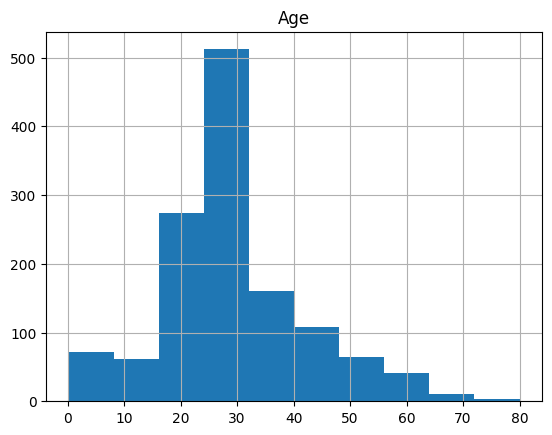

In [233]:
df.hist('Age')

C:\Users\raine\AppData\Local\Temp\ipykernel_19504\2615188596.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.hist('Age', by='Pclass')


array([[<Axes: title={'center': 'first'}>,
        <Axes: title={'center': 'second'}>],
       [<Axes: title={'center': 'third'}>, <Axes: >]], dtype=object)

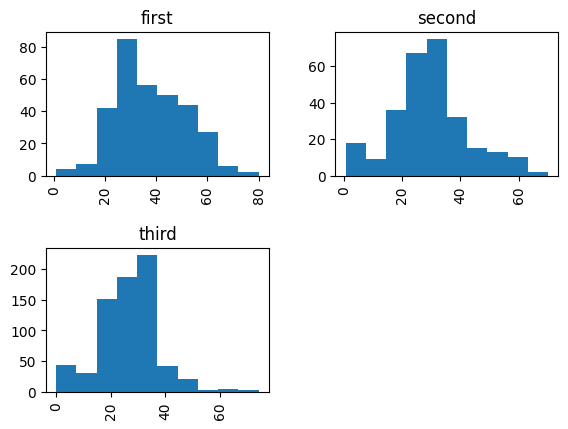

In [234]:
df.hist('Age', by='Pclass')

C:\Users\raine\AppData\Local\Temp\ipykernel_19504\3117820401.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.hist('Age', by='Survived', bins=3)


array([<Axes: title={'center': 'died'}>,
       <Axes: title={'center': 'survived'}>], dtype=object)

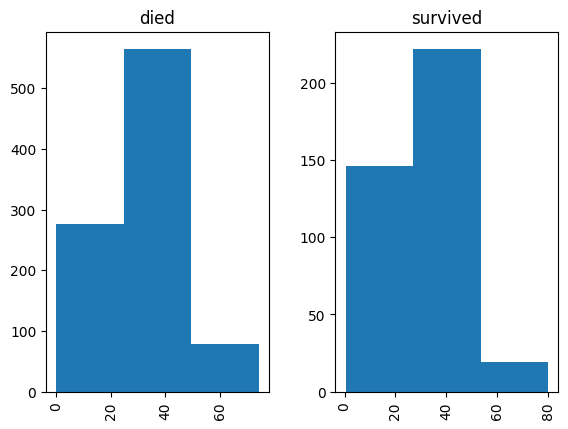

In [235]:
df.hist('Age', by='Survived', bins=3)

<Axes: >

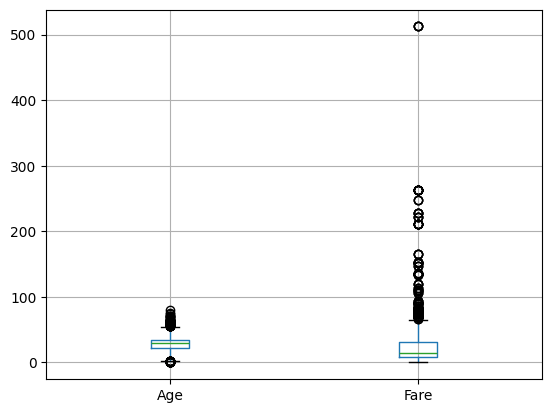

In [236]:
df.boxplot()